# SIFT: Scale Invariant Feature Transform

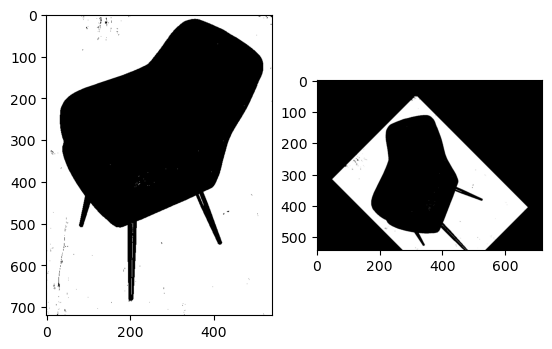

In [29]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

path = './chair.jpg'

img = cv.imread(path)
img = cv.resize(img, None, fx = 0.3, fy = 0.3)

img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
val, img_bin = cv.threshold(img_gray, 140, 255, cv.THRESH_BINARY)

height = img_bin.shape[0] 
width = img_bin.shape[1]
center = (int(height / 2) , int(width / 2))
scale = 0.7

M = cv.getRotationMatrix2D(center, 45, scale)
rotated = cv.warpAffine(img_bin, M, img_bin.shape)


plt.figure()
plt.subplot(121)
plt.imshow(img_bin, cmap = 'gray')
plt.subplot(122)
plt.imshow(rotated, cmap = 'gray')

plt.show()

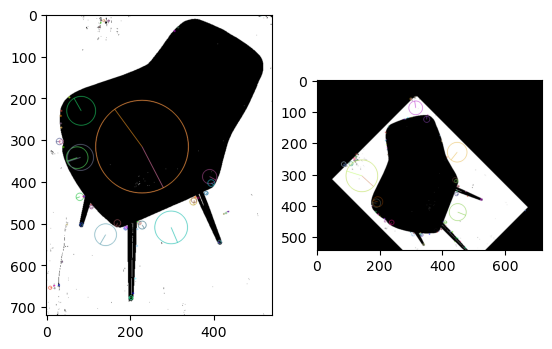

In [30]:
# create SIFT Detector object
sift = cv.SIFT_create()

# find keypoints in an image
keypoints1 = sift.detect(img_bin, None)
keypoints2 = sift.detect(rotated, None)

# draw keypoints by circles on their locations, including their size and direction
img_kp1 = cv.drawKeypoints(img_bin, keypoints1, None, flags = cv.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
img_kp2 = cv.drawKeypoints(rotated, keypoints2, None, flags = cv.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

plt.subplot(121)
plt.imshow(img_kp1, cmap = 'gray')
plt.subplot(122)
plt.imshow(img_kp2, cmap = 'gray')

plt.show()
